In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 1. Cargar Scores del Validation Set

In [3]:
# Buscar el directorio de salida más reciente
outputs_dir = Path('../outputs')
latest_run = sorted(outputs_dir.glob('resnet50_*'))[-1]
scores_path = latest_run / 'prediction_scores_validation.csv'

print(f"Cargando scores desde: {scores_path}")
df = pd.read_csv(scores_path)
print(f"Total de muestras: {len(df)}")
print(f"Benignas: {(df['true_label']==0).sum()}")
print(f"Malignas: {(df['true_label']==1).sum()}")
df.head()

Cargando scores desde: ../outputs/resnet50_20251224_170207/prediction_scores_validation.csv
Total de muestras: 11336
Benignas: 9561
Malignas: 1775


,true_label,predicted_score
0,1,0.990084
1,0,0.014795
2,0,0.160678
3,1,0.986189
4,0,0.034896


## 2. Histograma de Distribución de Scores

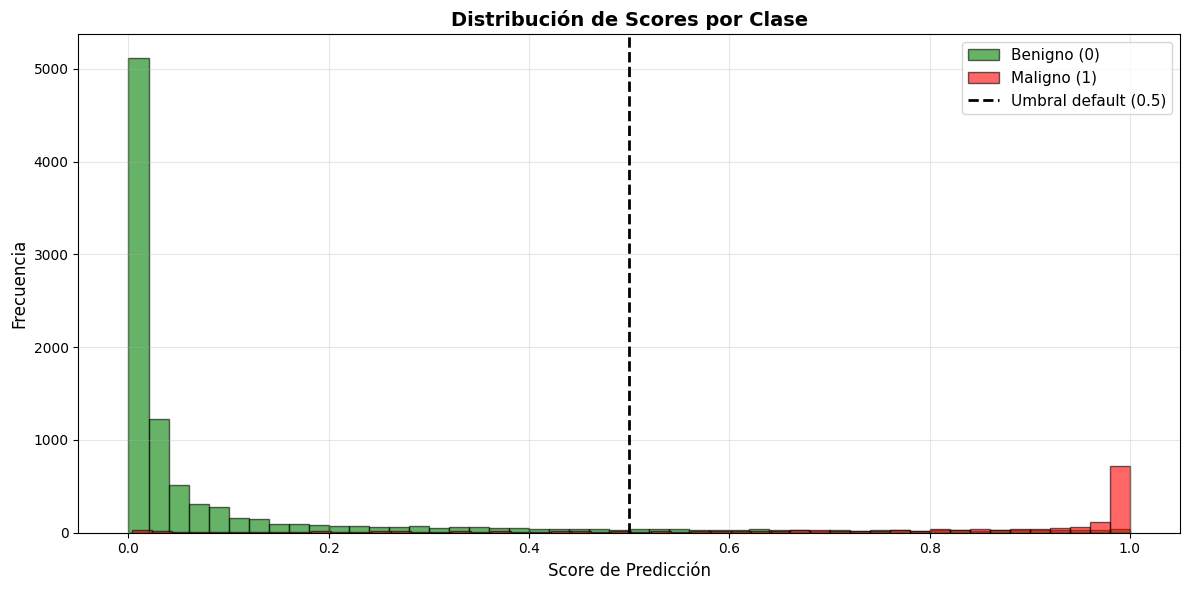


📊 Estadísticas de Scores:

Benignos:
  Media: 0.1089
  Mediana: 0.0174
  Std: 0.2085

Malignos:
  Media: 0.7865
  Mediana: 0.9464
  Std: 0.2892


In [4]:
# Separar scores por clase
scores_benign = df[df['true_label'] == 0]['predicted_score']
scores_malignant = df[df['true_label'] == 1]['predicted_score']

# Crear histograma
plt.figure(figsize=(12, 6))
plt.hist(scores_benign, bins=50, alpha=0.6, label='Benigno (0)', color='green', edgecolor='black')
plt.hist(scores_malignant, bins=50, alpha=0.6, label='Maligno (1)', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral default (0.5)')
plt.xlabel('Score de Predicción', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Scores por Clase', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'score_distribution.png', dpi=150)
plt.show()

print(f"\n📊 Estadísticas de Scores:")
print(f"\nBenignos:")
print(f"  Media: {scores_benign.mean():.4f}")
print(f"  Mediana: {scores_benign.median():.4f}")
print(f"  Std: {scores_benign.std():.4f}")
print(f"\nMalignos:")
print(f"  Media: {scores_malignant.mean():.4f}")
print(f"  Mediana: {scores_malignant.median():.4f}")
print(f"  Std: {scores_malignant.std():.4f}")

## 3. Análisis de Umbrales

Probar diferentes umbrales para encontrar el punto óptimo de balance.

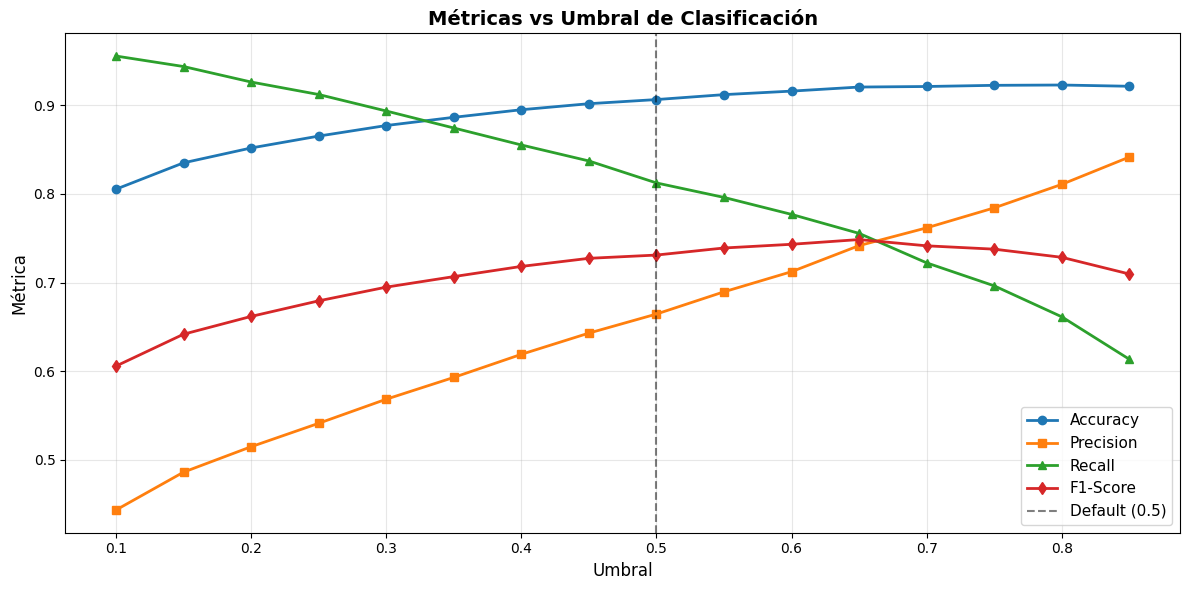


🎯 Umbrales Recomendados:

Mejor F1-Score: 0.65
  Accuracy: 0.9205
  Precision: 0.7417
  Recall: 0.7555
  F1: 0.7485

Mejor Accuracy: 0.80
  Accuracy: 0.9228
  Precision: 0.8108
  Recall: 0.6614
  F1: 0.7285


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Probar diferentes umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred = (df['predicted_score'] >= threshold).astype(int)
    y_true = df['true_label']
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

# Graficar métricas vs umbral
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results_df['threshold'], results_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'], 's-', label='Precision', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'], '^-', label='Recall', linewidth=2)
ax.plot(results_df['threshold'], results_df['f1'], 'd-', label='F1-Score', linewidth=2)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Umbral', fontsize=12)
ax.set_ylabel('Métrica', fontsize=12)
ax.set_title('Métricas vs Umbral de Clasificación', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'threshold_analysis.png', dpi=150)
plt.show()

# Encontrar mejores umbrales
best_f1_idx = results_df['f1'].idxmax()
best_acc_idx = results_df['accuracy'].idxmax()

print(f"\n🎯 Umbrales Recomendados:")
print(f"\nMejor F1-Score: {results_df.loc[best_f1_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_f1_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_f1_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_f1_idx, 'f1']:.4f}")

print(f"\nMejor Accuracy: {results_df.loc[best_acc_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_acc_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_acc_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_acc_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_acc_idx, 'f1']:.4f}")

## 4. Tabla Completa de Resultados

In [7]:
# Mostrar tabla completa
results_df.style.highlight_max(subset=['accuracy', 'precision', 'recall', 'f1'], color='lightgreen')

,threshold,accuracy,precision,recall,f1
0,0.100000,0.805311,0.443515,0.955493,0.605822
1,0.150000,0.835039,0.486212,0.943662,0.641762
2,0.200000,0.851800,0.514876,0.926197,0.661836
3,0.250000,0.865208,0.541291,0.912113,0.679396
4,0.300000,0.877117,0.568459,0.893521,0.694852
5,0.350000,0.886380,0.593045,0.874366,0.706740
6,0.400000,0.894936,0.619086,0.855211,0.718240
7,0.450000,0.901729,0.643012,0.837183,0.727362
8,0.500000,0.906404,0.664516,0.812394,0.731052
9,0.550000,0.911962,0.689605,0.796056,0.739017


## 5. Visualización de Separación de Clases

/tmp/ipykernel_1086944/509726732.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,


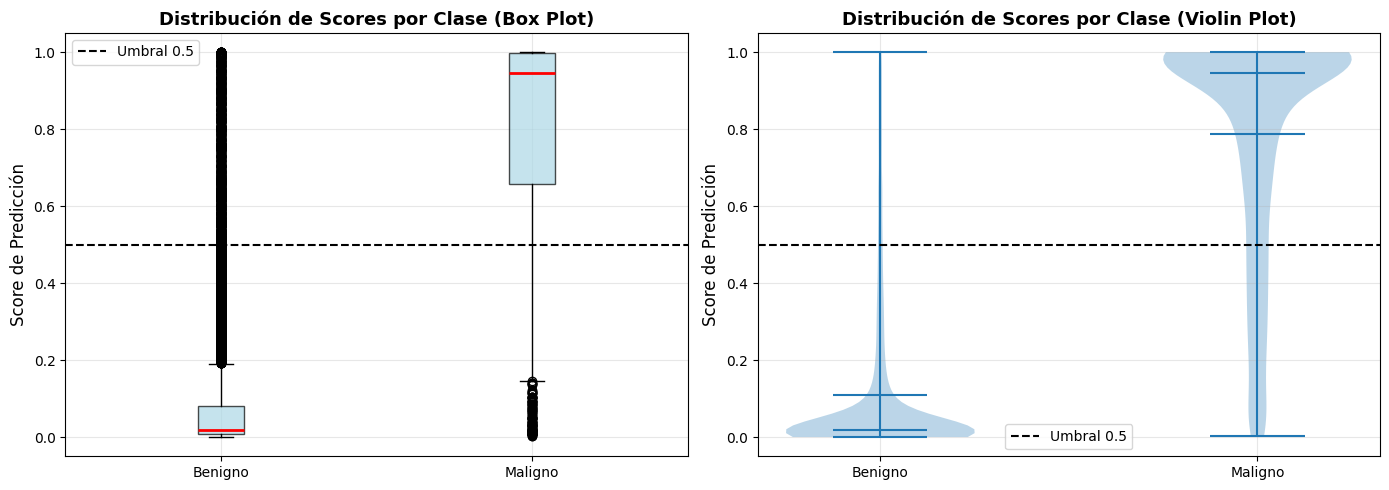

In [8]:
# Box plot para ver la separación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [scores_benign, scores_malignant]
ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax1.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax1.set_ylabel('Score de Predicción', fontsize=12)
ax1.set_title('Distribución de Scores por Clase (Box Plot)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Violin plot
positions = [1, 2]
parts = ax2.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True)
ax2.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax2.set_xticks(positions)
ax2.set_xticklabels(['Benigno', 'Maligno'])
ax2.set_ylabel('Score de Predicción', fontsize=12)
ax2.set_title('Distribución de Scores por Clase (Violin Plot)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(latest_run / 'figures' / 'score_separation.png', dpi=150)
plt.show()